<a href="https://colab.research.google.com/github/samarreguigui/summarization/blob/main/ERROR_4_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# RQ2 - Error Injection

Each xlsx has two summary columns:

- `summary_original` - the clean summary (baseline)
- `full_injected_summary` - the same summary with exactly one planted sentence



## 1. Setup

In [1]:
import importlib, subprocess, os, sys
for pip_name, imp in {'pymupdf':'fitz','tiktoken':'tiktoken','nltk':'nltk','pandas':'pandas',
                      'tqdm':'tqdm','openai':'openai','openpyxl':'openpyxl','matplotlib':'matplotlib'}.items():
    try: importlib.import_module(imp)
    except ImportError: subprocess.check_call(['pip','-q','install','--upgrade',pip_name])
import nltk; nltk.download('punkt', quiet=True); nltk.download('punkt_tab', quiet=True)
if not os.path.isdir('/content/FineSurE-ACL24'):
    subprocess.check_call(['git','clone','-q','https://github.com/DISL-Lab/FineSurE-ACL24.git'])
sys.path.insert(0, '/content/FineSurE-ACL24/finesure')
from google.colab import drive
drive.mount('/content/drive')
print('setup done')

Mounted at /content/drive
setup done


## 2. Config

In [5]:
from pathlib import Path

PROJECT   = Path('/content/drive/MyDrive/summarization')
PAPER_DIR = PROJECT / 'data' / 'paper'
INJ_ROOT  = PROJECT / 'data' / 'short_sum_with injected_Errors'
KEY_FILE  = PROJECT / 'api_key.txt'
WORK        = Path('/content/work_rq2'); CACHE = WORK/'cache'; RESULTS = WORK/'results'; FIG = WORK/'figures'
DRIVE_OUT   = PROJECT / 'error_injection_eval_run'
for d in [WORK, CACHE, RESULTS, FIG]: d.mkdir(parents=True, exist_ok=True)

# restore previous cache + results from Drive so re-runs are free
import shutil
for sub, tgt in [('cache', CACHE), ('results', RESULTS)]:
    src = DRIVE_OUT / sub
    if src.exists():
        for f in src.glob('*'):
            if not (tgt/f.name).exists(): shutil.copy2(f, tgt/f.name)

MODEL, OPENROUTER_URL, TEMPERATURE = 'openai/gpt-4o-2024-05-13', 'https://openrouter.ai/api/v1', 0.0

# canonical FineSurE category names, and which returned categories count as "right type"
CATS = ['no error','out-of-context error','entity error','predicate error','circumstantial error',
        'grammatical error','coreference error','linking error','other error']
def norm(s): return str(s).replace('-',' ').strip().lower()
CANON = {norm(c): c for c in CATS}
def canon(s): return CANON.get(norm(s), norm(s))
LENIENT = {'entity error':{'entity error'},
           'circumstantial error':{'circumstantial error','entity error'},
           'out-of-context error':{'out-of-context error','other error'},
           'grammatical error':{'grammatical error'}}
print('config ready')

config ready


## 3. Helpers

In [3]:
import fitz, re, hashlib, json, time, ast, difflib
import tiktoken
from nltk.tokenize import sent_tokenize
ENC = tiktoken.get_encoding('cl100k_base')

def read_pdf(p):
    d = fitz.open(p); t = '\n'.join(pg.get_text() for pg in d); d.close(); return t
def clean_article(raw):
    raw = re.split(r'\n\s*(References|REFERENCES|Bibliography)\b', raw, maxsplit=1)[0]
    return re.sub(r'\n{3,}','\n\n', re.sub(r'[ \t]+',' ', raw)).strip()
def sentences_of(t): return [s.strip() for s in sent_tokenize(t) if s.strip()]
def find_article(pid):
    m = sorted(PAPER_DIR.glob(f'{pid}_*.pdf')); assert m, f'no PDF for paper {pid}'; return m[0]

def match_idx(sents, target):
    '''index of the sentence closest to `target`.'''
    t = target.strip()
    for i,s in enumerate(sents):
        if s.strip()==t: return i
    for i,s in enumerate(sents):
        if t in s or s in t: return i
    return max(range(len(sents)), key=lambda i: difflib.SequenceMatcher(None, sents[i], t).ratio())

def align(isents, csents, thresh=0.65):
    '''best 1-1 match injected->clean; None = new sentence (the appended fabrication).'''
    cand = sorted(((difflib.SequenceMatcher(None,s,c).ratio(), i, j)
                   for i,s in enumerate(isents) for j,c in enumerate(csents)), reverse=True)
    ui, uj, m = set(), set(), {}
    for r,i,j in cand:
        if r<thresh or i in ui or j in uj: continue
        ui.add(i); uj.add(j); m[i]=j
    return {i: m.get(i) for i in range(len(isents))}
print('helpers ready')

helpers ready


## 4. FineSurE judge (cached)

In [6]:
import openai
from utils import (get_fact_checking_prompt, parsing_llm_fact_checking_output,
                   compute_faithfulness_percentage_score)

client = openai.OpenAI(api_key=KEY_FILE.read_text().strip(), base_url=OPENROUTER_URL)

def _key(prompt): return hashlib.sha256(f'{MODEL}|{TEMPERATURE}|{prompt}'.encode()).hexdigest()[:24]
def get_response(prompt, tries=3):
    cf = CACHE / f'{_key(prompt)}.json'
    if cf.exists(): return json.loads(cf.read_text())['response']
    last = None
    for a in range(tries):
        try:
            r = client.chat.completions.create(model=MODEL, temperature=TEMPERATURE,
                                               messages=[{'role':'user','content':prompt}])
            txt = r.choices[0].message.content
            cf.write_text(json.dumps({'prompt':prompt,'response':txt})); return txt
        except Exception as e:
            last = e; time.sleep(2**a)
    raise RuntimeError(f'API failed: {last}')

def robust_parse(raw):
    txt = (raw or '').replace('```json','').replace('```','')
    s, e = txt.find('['), txt.rfind(']')          # last ] so a bracket inside a sentence won't truncate
    if s!=-1 and e>s:
        try:
            labels, types = [], []
            for it in ast.literal_eval(txt[s:e+1]):
                if isinstance(it, dict):
                    labels.append(0 if norm(it.get('category',''))=='no error' else 1)
                    types.append(str(it.get('category','')).strip())
            if labels: return labels, types
        except Exception: pass
    return parsing_llm_fact_checking_output(raw)

def judge(article, sents):
    '''one label per sentence; re-asks once if the count is off.'''
    raw = get_response(get_fact_checking_prompt(input=article, sentences=sents))
    pl, pt = robust_parse(raw)
    if len(pl)==len(sents): return pl, pt
    raw2 = get_response(get_fact_checking_prompt(input=article, sentences=sents)
                        + f'\nReturn exactly {len(sents)} dictionaries, one per sentence, in order.')
    pl2, pt2 = robust_parse(raw2)
    return (pl2, pt2) if len(pl2)==len(sents) else (pl, pt)
print('judge ready')

judge ready


## 5. Load injections

Reads `summary_original` (clean) and `full_injected_summary` (injected) from every xlsx. Duplicate
columns (pandas suffixes them `.1`) are merged; blanks fall back to the other copy. Any row that is
skipped - because a summary column is empty or a header is misspelled - is **printed**, and a
coverage check reports which (type x summary) cells are missing so nothing disappears silently.

In [7]:
import pandas as pd
def _s(v): return '' if pd.isna(v) else str(v).strip()

rows, skipped = [], []
for folder in sorted(p for p in INJ_ROOT.iterdir() if p.is_dir() and not p.name.startswith('_')):
    etype = canon(folder.name)
    files = [x for x in sorted(folder.glob('*.xlsx')) if not x.name.startswith('~$')]
    if not files:
        print(f'(no xlsx) {etype}'); continue
    for xf in files:
        df = pd.read_excel(xf); df.columns = [str(c).strip() for c in df.columns]
        for c in [c for c in df.columns if re.search(r'\.\d+$', c)]:      # merge duplicate columns
            base = re.sub(r'\.\d+$','', c)
            if base in df.columns: df[base] = [_s(a) or _s(b) for a,b in zip(df[base], df[c])]
            df = df.drop(columns=[c])
        # accept a few header spellings for the clean column
        for alias in ['full_original_summary','original_summary','summary_original ']:
            if alias in df.columns and 'summary_original' not in df.columns:
                df = df.rename(columns={alias:'summary_original'})
        have = {'full_injected_summary','summary_original'} <= set(df.columns)
        if not have:
            print(f'!! {etype} / {xf.name}: missing a required column. columns present: {list(df.columns)}')
        for _, r in df.iterrows():
            name = _s(r.get('summary'))
            inj_t, orig = _s(r.get('full_injected_summary')), _s(r.get('summary_original'))
            if not name: continue
            if not inj_t or not orig:
                skipped.append((etype, name,
                                'full_injected_summary empty' if not inj_t else 'summary_original empty'))
                continue
            rows.append({'error_type':etype, 'summary':name, 'paper_id':name[:2],
                         'injected_sentence':_s(r.get('injected_sentence')),
                         'what_changed':_s(r.get('what_changed')), 'clean':orig, 'injected':inj_t})
data = pd.DataFrame(rows).drop_duplicates(['error_type','summary']).reset_index(drop=True)

print('loaded:', len(data))
print(data['error_type'].value_counts().to_string())

# --- coverage check: every error type should cover every summary name ---
all_summaries = sorted(data['summary'].unique())
print(f'\n{len(all_summaries)} distinct summaries seen:', all_summaries)
print('\ncoverage (each type should have all summaries):')
for et, grp in data.groupby('error_type'):
    missing = sorted(set(all_summaries) - set(grp['summary']))
    print(f'  {et}: {len(grp)}/{len(all_summaries)}' + (f'   MISSING: {missing}' if missing else '   (complete)'))
if skipped:
    print('\nSKIPPED rows (blank summary cell - fix these in the xlsx):')
    for et, name, why in skipped:
        print(f'  {et} / {name}: {why}')
data.head()

loaded: 32
error_type
circumstantial error    8
entity error            8
grammatical error       8
out-of-context error    8

8 distinct summaries seen: ['01_sum1_short', '02_sum1_short', '03_sum2_short', '04_sum1_short', '04_sum2_short', '05_sum1_short', '05_sum2_short', '06_sum_short']

coverage (each type should have all summaries):
  circumstantial error: 8/8   (complete)
  entity error: 8/8   (complete)
  grammatical error: 8/8   (complete)
  out-of-context error: 8/8   (complete)


,error_type,summary,paper_id,injected_sentence,what_changed,clean,injected
0,circumstantial error,01_sum1_short,01,Importantly LLMs perform better on human gener...,"Added false circumstantial condition ""only whe...",Background: The current trend towards evaluati...,Background: The current trend towards evaluati...
1,circumstantial error,02_sum1_short,02,Environmental costs are significant - training...,"Added false quantitative circumstance ""over 80...",Background: The starting point is the trend in...,Background: The starting point is the trend in...
2,circumstantial error,03_sum2_short,03,"on NPI illusions, the LMs and performed worse ...","Quantity ""other two types"" changed to ""other f...",Background:\nHumans tend to make errors during...,Background: Humans tend to make errors during ...
3,circumstantial error,04_sum1_short,04,"Well, I learned that smell-based embeddings ca...",Scope circumstance replaced with a contradicto...,Background:\nThe starting point of the paper i...,Background: The starting point of the paper is...
4,circumstantial error,04_sum2_short,04,The study found that the best olfactory repres...,"Quantity ""30 dimensions"" changed to ""300 dimen...",Background: The authors question why the proce...,Background: The authors question why the proce...


## 6. Score every injection

For each injection we judge the clean summary and the injected summary, then record:

- **detected** - the planted sentence is flagged in the injected run but was *not* flagged in the
  clean run. The planted sentence is the anchor sentence (`injected_sentence`) plus any sentence with
  no clean counterpart (an appended fabrication).
- **right type** - the flagged category matches the planted type (strict) or a near-equivalent (lenient).
- **faithfulness delta** - injected faithfulness minus clean faithfulness.
- **collateral** - other, matched sentences newly flagged only after the injection.

In [12]:
from tqdm.auto import tqdm

_art = {}
def article_for(pid):
    if pid not in _art: _art[pid] = clean_article(read_pdf(find_article(pid)))
    return _art[pid]

def run(name, text):                          # judge with a small on-disk cache per (name, text)
    cf = RESULTS / f'{hashlib.sha256((name+text).encode()).hexdigest()[:20]}.json'
    if cf.exists():
        d = json.loads(cf.read_text()); return d['pl'], d['pt'], d['sents']
    sents = sentences_of(text); pl, pt = judge(article_for(name[:2]), sents)
    cf.write_text(json.dumps({'pl':pl,'pt':pt,'sents':sents})); return pl, pt, sents

out = []
for _, r in tqdm(list(data.iterrows()), total=len(data)):
    name, etype = r['summary'], r['error_type']
    cpl, cpt, csents = run(name+'__clean', r['clean'])
    ipl, ipt, isents = run(name+'__inj',   r['injected'])
    if len(ipl)!=len(isents) or len(cpl)!=len(csents):
        print('parse mismatch, skipped:', etype, name); continue

    amap = align(isents, csents)
    new  = [i for i,j in amap.items() if j is None]
    anchor = match_idx(isents, r['injected_sentence'])
    target = sorted(set(new) | {anchor})
    def cflag(i): j = amap.get(i); return cpl[j] if (j is not None and j<len(cpl)) else 0

    newly = [i for i in target if ipl[i]==1 and (amap.get(i) is None or cflag(i)==0)]
    detected = int(bool(newly))
    ret_idx  = (newly or [i for i in target if ipl[i]==1] or [anchor])[0]
    returned = canon(ipt[ret_idx]) if ret_idx<len(ipt) and detected else 'no error'
    strict   = int(detected and returned==etype)
    lenient  = int(detected and returned in LENIENT.get(etype, {etype}))

    cfaith, ifaith = compute_faithfulness_percentage_score(cpl), compute_faithfulness_percentage_score(ipl)
    matched = [i for i in range(len(isents)) if amap.get(i) is not None and i not in target]
    collateral = sum(1 for i in matched if ipl[i]==1 and cflag(i)==0)

    out.append({'error_type':etype,'summary':name,'detected':detected,
                'returned':returned,'expected':etype,'strict':strict,'lenient':lenient,
                'faith_clean':round(cfaith,3),'faith_injected':round(ifaith,3),
                'faith_delta':round(ifaith-cfaith,3),'collateral':collateral,
                'injected_sentence':r['injected_sentence'],'what_changed':r['what_changed']})
res = pd.DataFrame(out); res.to_csv(RESULTS/'injection_eval.csv', index=False)
print('scored:', len(res))
res.head(10)

  0%|          | 0/32 [00:00<?, ?it/s]

parse mismatch, skipped: circumstantial error 04_sum2_short
parse mismatch, skipped: entity error 04_sum2_short
parse mismatch, skipped: grammatical error 04_sum2_short
parse mismatch, skipped: out-of-context error 04_sum2_short
scored: 28


,error_type,summary,detected,returned,expected,strict,lenient,faith_clean,faith_injected,faith_delta,collateral,injected_sentence,what_changed
0,circumstantial error,01_sum1_short,1,out-of-context error,circumstantial error,0,0,1.000,0.875,-0.125,0,Importantly LLMs perform better on human gener...,"Added false circumstantial condition ""only whe..."
1,circumstantial error,02_sum1_short,1,out-of-context error,circumstantial error,0,0,1.000,0.923,-0.077,0,Environmental costs are significant - training...,"Added false quantitative circumstance ""over 80..."
2,circumstantial error,03_sum2_short,1,out-of-context error,circumstantial error,0,0,0.909,0.727,-0.182,1,"on NPI illusions, the LMs and performed worse ...","Quantity ""other two types"" changed to ""other f..."
3,circumstantial error,04_sum1_short,1,entity error,circumstantial error,0,1,1.000,0.833,-0.167,0,"Well, I learned that smell-based embeddings ca...",Scope circumstance replaced with a contradicto...
4,circumstantial error,05_sum1_short,1,out-of-context error,circumstantial error,0,0,1.000,0.800,-0.200,0,Background: Language processing occurs in comp...,"Added false circumstantial restriction ""only i..."
5,circumstantial error,05_sum2_short,1,out-of-context error,circumstantial error,0,0,1.000,0.875,-0.125,0,While larger models generally align better wit...,"Quantity ""30 billion parameters"" changed to ""3..."
6,circumstantial error,06_sum_short,1,circumstantial error,circumstantial error,1,1,1.000,0.833,-0.167,0,This paper proposes a new benchmark (PlanBench...,"Added false date circumstance ""in 2019"" (not i..."
7,entity error,01_sum1_short,1,entity error,entity error,1,1,1.000,0.875,-0.125,0,The benchmark dataset collection “JudgeLM” use...,"Benchmark name ""judge-bench"" replaced with ""Ju..."
8,entity error,02_sum1_short,1,out-of-context error,entity error,0,0,1.000,0.846,-0.154,1,The starting point is the trend in NLP (Natura...,"Model name ""GPT-3"" changed to ""GPT-4"" (entity ..."
9,entity error,03_sum2_short,0,no error,entity error,0,0,0.636,0.636,0.000,0,"Do the analyzed LMs(BERT, RoBERTa, GPT-3 and T...","Model name ""GPT-2"" changed to ""T5"" (entity not..."


## 7. Detection & type accuracy

In [13]:
print('Detection rate           : %.1f%%' % (100*res.detected.mean()))
det = res[res.detected==1]
print('Right type (strict)  |found: %.1f%%' % (100*det.strict.mean()))
print('Right type (lenient) |found: %.1f%%' % (100*det.lenient.mean()))
print('\n-- detection rate by type --')
print((res.groupby('error_type').detected.mean()*100).round(1).to_string())
print('\n-- lenient type accuracy among found --')
print((det.groupby('error_type').lenient.mean()*100).round(1).to_string())
print('\n-- per injection --')
with pd.option_context('display.max_rows',None,'display.max_colwidth',28):
    print(res[['error_type','summary','detected','returned','expected','lenient']].to_string(index=False))

Detection rate           : 92.9%
Right type (strict)  |found: 53.8%
Right type (lenient) |found: 57.7%

-- detection rate by type --
error_type
circumstantial error    100.0
entity error             85.7
grammatical error        85.7
out-of-context error    100.0

-- lenient type accuracy among found --
error_type
circumstantial error    28.6
entity error            50.0
grammatical error       66.7
out-of-context error    85.7

-- per injection --
          error_type       summary  detected             returned             expected  lenient
circumstantial error 01_sum1_short         1 out-of-context error circumstantial error        0
circumstantial error 02_sum1_short         1 out-of-context error circumstantial error        0
circumstantial error 03_sum2_short         1 out-of-context error circumstantial error        0
circumstantial error 04_sum1_short         1         entity error circumstantial error        1
circumstantial error 05_sum1_short         1 out-of-context error c

## 8. Confusion matrix (planted vs returned)

returned              no error  out-of-context error  entity error  predicate error  circumstantial error  grammatical error  coreference error  linking error  other error
error_type                                                                                                                                                                 
circumstantial error         0                     5             1                0                     1                  0                  0              0            0
entity error                 1                     3             3                0                     0                  0                  0              0            0
grammatical error            1                     2             0                0                     0                  4                  0              0            0
out-of-context error         0                     6             1                0                     0                  0                

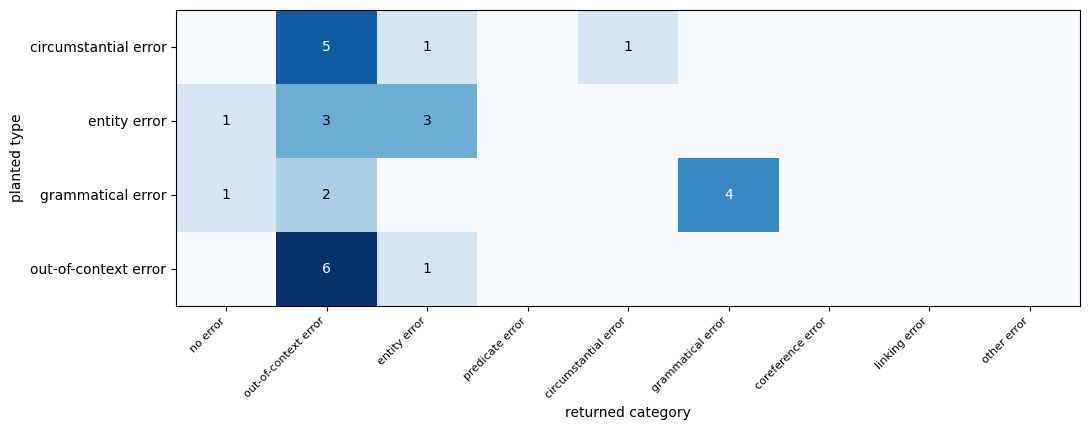

In [14]:
import numpy as np, matplotlib.pyplot as plt
cm = res.copy(); cm['returned'] = cm['returned'].where(cm.detected==1, 'no error')
types = sorted(res.error_type.unique())
conf = (cm.pivot_table(index='error_type', columns='returned', values='summary', aggfunc='count', fill_value=0)
          .reindex(index=types).reindex(columns=CATS, fill_value=0))
conf.to_csv(RESULTS/'confusion_matrix.csv'); print(conf.to_string())
fig, ax = plt.subplots(figsize=(11, 0.7*len(types)+1.6))
im = ax.imshow(conf.values, cmap='Blues', aspect='auto')
ax.set_xticks(range(len(CATS))); ax.set_xticklabels(CATS, rotation=45, ha='right', fontsize=8)
ax.set_yticks(range(len(types))); ax.set_yticklabels(types)
for a in range(conf.shape[0]):
    for b in range(conf.shape[1]):
        v = conf.values[a,b]
        if v: ax.text(b,a,int(v),ha='center',va='center',
                      color='white' if v>conf.values.max()/2 else 'black')
ax.set_xlabel('returned category'); ax.set_ylabel('planted type')
plt.tight_layout(); fig.savefig(FIG/'confusion_matrix.png', dpi=120); plt.show()

## 9. Faithfulness impact

                      n  detect_rate  faith_clean  faith_injected  faith_delta  collateral
error_type                                                                                
circumstantial error  7        100.0        0.987           0.838       -0.149       0.143
entity error          7         85.7        0.948           0.785       -0.163       0.286
grammatical error     7         85.7        0.930           0.709       -0.221       0.143
out-of-context error  7        100.0        0.930           0.809       -0.122       0.143

injections with collateral flags: 5 / 28
mean faithfulness drop: 0.164


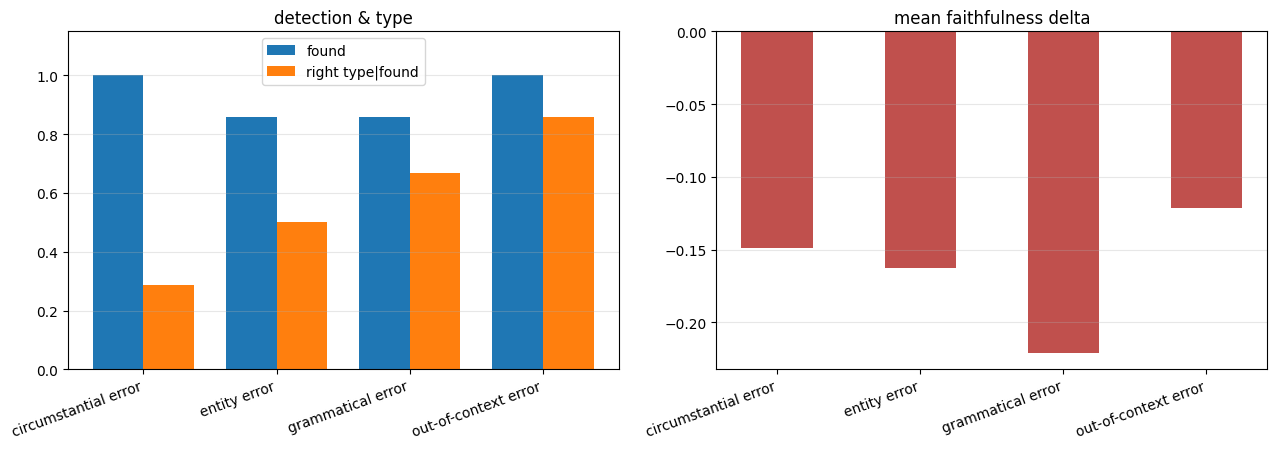

In [15]:
g = res.groupby('error_type').agg(
        n=('summary','size'), detect_rate=('detected','mean'),
        faith_clean=('faith_clean','mean'), faith_injected=('faith_injected','mean'),
        faith_delta=('faith_delta','mean'), collateral=('collateral','mean')).round(3)
g['detect_rate'] = (g.detect_rate*100).round(1)
print(g.to_string())
print('\ninjections with collateral flags:', int((res.collateral>0).sum()), '/', len(res))
print('mean faithfulness drop:', round(-res.faith_delta.mean(), 3))

import numpy as np, matplotlib.pyplot as plt
types = sorted(res.error_type.unique()); x = np.arange(len(types)); w = 0.38
fig, ax = plt.subplots(1,2, figsize=(13,4.6))
d = res.groupby('error_type').detected.mean().reindex(types)
t = res[res.detected==1].groupby('error_type').lenient.mean().reindex(types).fillna(0)
ax[0].bar(x-w/2, d.values, w, label='found'); ax[0].bar(x+w/2, t.values, w, label='right type|found')
ax[0].set_xticks(x); ax[0].set_xticklabels(types, rotation=20, ha='right'); ax[0].set_ylim(0,1.15)
ax[0].set_title('detection & type'); ax[0].legend(); ax[0].grid(axis='y', alpha=.3)
dl = res.groupby('error_type').faith_delta.mean().reindex(types)
ax[1].bar(x, dl.values, 0.5, color='#c0504d'); ax[1].axhline(0, color='k', lw=.6)
ax[1].set_xticks(x); ax[1].set_xticklabels(types, rotation=20, ha='right')
ax[1].set_title('mean faithfulness delta'); ax[1].grid(axis='y', alpha=.3)
plt.tight_layout(); fig.savefig(FIG/'faithfulness_impact.png', dpi=120); plt.show()

## 10. Misses

In [16]:
miss = res[res.detected==0][['error_type','summary','injected_sentence','what_changed']]
print('missed %d / %d' % (len(miss), len(res)))
with pd.option_context('display.max_rows',None,'display.max_colwidth',70):
    print(miss.to_string(index=False))

missed 2 / 28
       error_type       summary                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                           injected_sentenc

## 11. Save to Drive

In [17]:
import shutil
DRIVE_OUT.mkdir(parents=True, exist_ok=True)
for sub in ['results','figures','cache']:
    s = WORK/sub; o = DRIVE_OUT/sub
    if not s.exists(): continue
    if o.exists(): shutil.rmtree(o)
    shutil.copytree(s, o)
print('saved to', DRIVE_OUT)

saved to /content/drive/MyDrive/summarization/error_injection_eval_run
